# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

In [64]:
cd ..

E:\notebooks


In [65]:
# Import required libraries
import os
import re
from pathlib import Path

# Ensure relative paths used by project modules resolve correctly
os.chdir("E:/notebooks/MultimodalTweetsClassification")

from exp.Data_Reading_And_Preprocessing_CrisisMMD_V2 import get_tsv_data_files, get_dataframe

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm.auto import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading and Preprocessing

In [66]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('E:/notebooks/MultimodalTweetsClassification')
data_info_text_image, test_data_info_text_image = get_dataframe(train_tsv, dev_tsv, test_tsv, info, path)

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {data_info_text_image['is_valid'].value_counts()[0]}")
print(f"valid set: {data_info_text_image['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
[train] shape=(13607, 9)
[train] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=13607 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=13607
[Image validation] kept=13607 removed_invalid=0 from_total=13607
[train] avg_token_count=13.22 | median_token_count=13.00
[train] label_text distribution:
informative        9637
not_informative    3970
Name: label_text, dtype: int64
[train] label_image distribution:
informative        7058
not_informative    6549
Name: label_image, dtype: int64
[dev] shape=(2237, 9)
[dev] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=2237 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=2237
[Image validation] kept=2237 removed_invalid=0 from_total=2237
[dev] avg_token_count=13.19

## 2. Cross-Attention Model Architecture

We'll implement a cross-attention mechanism to fuse text and image features effectively.

In [67]:
class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, x, context):
        q = self.query(x)
        k = self.key(context)
        v = self.value(context)

        attention = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attention = F.softmax(attention, dim=-1)
        out = torch.matmul(attention, v)
        return out


class MultimodalClassifier(nn.Module):
    def __init__(self, hidden_dim=512, num_classes=2, bert_model=None):
        super().__init__()

        # Image encoder (ResNet50)
        self.image_encoder = resnet50(pretrained=True)
        self.image_encoder.fc = nn.Identity()  # Remove final classification layer

        # Text encoder (BERT)
        self.text_encoder = bert_model if bert_model is not None else BertModel.from_pretrained(
            'bert-base-uncased')

        # Project both modalities to same dimension
        self.image_projection = nn.Linear(
            2048, hidden_dim)  # ResNet50 output dim is 2048
        self.text_projection = nn.Linear(
            768, hidden_dim)    # BERT output dim is 768

        # Cross attention layers
        self.img2text_attention = CrossAttention(hidden_dim)
        self.text2img_attention = CrossAttention(hidden_dim)

        # Final classification layers
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, images, input_ids, attention_mask):
        # Image features
        img_features = self.image_encoder(images)  # [batch_size, 2048]
        img_features = self.image_projection(
            img_features)  # [batch_size, hidden_dim]

        # Text features
        text_outputs = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask)
        # Get the hidden states from the output tuple
        # First element contains hidden states
        last_hidden_state = text_outputs[0]
        text_features = last_hidden_state[:, 0, :]  # Use [CLS] token
        text_features = self.text_projection(
            text_features)  # [batch_size, hidden_dim]

        # Cross attention
        img_attended = self.text2img_attention(
            img_features.unsqueeze(1), text_features.unsqueeze(1))
        text_attended = self.img2text_attention(
            text_features.unsqueeze(1), img_features.unsqueeze(1))

        # Combine attended features
        fused_features = torch.cat(
            [img_attended.squeeze(1), text_attended.squeeze(1)], dim=-1)

        # Final classification
        output = self.fusion(fused_features)
        return output

In [68]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "E:/notebooks/MultimodalTweetsClassification/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: E:/notebooks/MultimodalTweetsClassification/bert_local


## 3. Dataset and DataLoader

In [69]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        # Create label mapping
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            # Process text
            text = str(row['tweet_text'])  # Ensure text is string
            # Don't use return_tensors='pt' here, we'll convert to tensor manually
            encoding = self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None  # Return Python lists instead of tensors
            )

            # Process image
            raw_image = str(row['image']).strip()
            drive_match = re.search(r"[A-Za-z]:[\\/].*", raw_image)
            if drive_match:
                normalized_image = drive_match.group(0)
                image_path = Path(normalized_image)
            else:
                normalized_image = raw_image.lstrip('\\/')
                image_path = self.image_path / normalized_image

            image = Image.open(str(image_path)).convert('RGB')
            if self.transform:
                image = self.transform(image)

            # Convert text label to numeric using label map
            label = torch.tensor(
                self.label_map[row['label_text']], dtype=torch.long)

            # Convert to tensors without batch dimension
            input_ids = torch.tensor(encoding['input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(
                encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            print(f"Text: {text}")
            print(f"Raw image field: {raw_image}")
            print(f"Image path: {image_path}")
            raise

        # Ensure all tensors have the expected size
        if input_ids.dim() == 0:
            input_ids = input_ids.unsqueeze(0)
        if attention_mask.dim() == 0:
            attention_mask = attention_mask.unsqueeze(0)

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }


# Initialize tokenizer and transforms
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_path)  # Use the same model path as BERT
    print("Tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading tokenizer: {str(e)}")
    print("Falling back to base BERT tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("Base BERT tokenizer loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df = data_info_text_image[data_info_text_image['is_valid']]
test_df = test_data_info_text_image

print("Creating datasets...")
train_dataset = MultimodalDataset(
    train_df, tokenizer, path/'data/CrisisMMD_v2', transform)
val_dataset = MultimodalDataset(
    val_df, tokenizer, path/'data/CrisisMMD_v2', transform)
test_dataset = MultimodalDataset(
    test_df, tokenizer, path/'data/CrisisMMD_v2', transform)
print("Datasets created successfully!")

# Create custom collate function to handle batching


def custom_collate(batch):
    # Sort batch by sequence length (in descending order) to handle padding properly
    batch = sorted(batch, key=lambda x: len(x['input_ids']), reverse=True)

    # Get maximum sequence length in this batch
    max_len = len(batch[0]['input_ids'])

    # Initialize lists to store batch items
    images = []
    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        # Handle images
        images.append(item['image'])

        # Pad input_ids and attention_mask if needed
        seq_len = len(item['input_ids'])
        if seq_len < max_len:
            # Padding token id is usually 0 for BERT
            padding = torch.zeros(max_len - seq_len, dtype=torch.long)
            item['input_ids'] = torch.cat([item['input_ids'], padding])
            item['attention_mask'] = torch.cat(
                [item['attention_mask'], padding])

        input_ids.append(item['input_ids'])
        attention_masks.append(item['attention_mask'])
        labels.append(item['label'])

    # Stack all tensors
    images = torch.stack(images)
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.stack(labels)

    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'label': labels
    }

# Create data loaders with proper multiprocessing settings


def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


print("Creating data loaders...")
# Create data loaders with adjusted settings and custom collate function
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

print("Data loaders created successfully!")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Loading tokenizer...
Tokenizer loaded successfully!
Creating datasets...
Datasets created successfully!
Creating data loaders...
Data loaders created successfully!
Number of training samples: 13607
Number of validation samples: 2237
Number of test samples: 2237


In [70]:
# Quick sanity check for the previously failing sample index
_sample = train_dataset[10547]
print("Sample 10547 loaded successfully.")
print(f"Resolved image tensor shape: {_sample['image'].shape}")

Sample 10547 loaded successfully.
Resolved image tensor shape: torch.Size([3, 224, 224])


## 4. Training and Evaluation Functions

In [71]:
from sklearn.metrics import classification_report, f1_score

def train_epoch(model, train_loader, criterion, optimizer, device, log_every=25):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(train_loader, desc='Training', leave=True)
    for batch_idx, batch in enumerate(progress_bar, 1):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        running_acc = 100.0 * correct / total
        running_loss = total_loss / batch_idx
        progress_bar.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_acc:.2f}%")

        # Force visible logs during long epochs, even if tqdm bar rendering is delayed.
        if (batch_idx % log_every == 0) or (batch_idx == len(train_loader)):
            print(f"Loss: {running_loss:.4f}, Acc: {running_acc:.2f}%", flush=True)

    train_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(train_loader), 100.0 * correct / total, train_f1


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc='Evaluating', leave=True)
        for batch_idx, batch in enumerate(progress_bar, 1):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            running_acc = 100.0 * correct / total
            running_loss = total_loss / batch_idx
            progress_bar.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_acc:.2f}%")

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds))

    return total_loss / len(val_loader), 100.0 * correct / total, val_f1

## 5. Model Training

In [72]:
# Load local BERT model
print("Loading BERT model from local path...")
try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT model loaded successfully!")
except Exception as e:
    print(f"Error loading BERT model: {str(e)}")
    raise

# Initialize model with local BERT and correct number of classes
model = MultimodalClassifier(
    bert_model=bert_model, num_classes=num_labels).to(device)

# Ensure BERT is in training mode
model.text_encoder.train()

# Lists to store metrics for plotting
train_losses = []
train_accs = []
train_f1s = []
val_losses = []
val_accs = []
val_f1s = []

# Training parameters
num_epochs = 10
criterion = nn.CrossEntropyLoss()
# Lower learning rate for more stable training
optimizer = AdamW([
    {'params': model.image_encoder.parameters(), 'lr': 1e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-6},  # Lower LR for BERT
    {'params': list(model.image_projection.parameters()) +
     list(model.text_projection.parameters()) +
     list(model.img2text_attention.parameters()) +
     list(model.text2img_attention.parameters()) +
     list(model.fusion.parameters()), 'lr': 2e-5}
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs)

# Training loop
best_val_acc = 0
print(f"Training: 0%|          | 0/{len(train_loader)} [00:00<?, ?it/s]\n")

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)
    print(f"Training steps this epoch: {len(train_loader)}")

    train_loss, train_acc, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device, log_every=25)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f'\nTrain Loss: {train_loss:.4f} Acc: {train_acc:.2f}% F1: {train_f1:.4f}')
    print(f'Val   Loss: {val_loss:.4f} Acc: {val_acc:.2f}% F1: {val_f1:.4f}')

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), path /
                   'models/informative_Attention_graph_V2.pth')
        print(f'Saved new best model with validation accuracy: {val_acc:.2f}%')
    print('')

Loading BERT model from local path...
BERT model loaded successfully!


Training: 0%|          | 0/851 [00:00<?, ?it/s]

Epoch 1/10
----------
Training steps this epoch: 851


Loss: 0.5805, Acc: 70.00%


Loss: 0.5209, Acc: 74.62%


Loss: 0.4737, Acc: 78.58%


...

Loss: 0.0072, Acc: 99.82%


Loss: 0.0070, Acc: 99.82%


Loss: 0.0070, Acc: 99.82%




Training: 100%|██████████| 851/851 [2:14:12<00:00,  9.46s/it, acc=99.82%, loss=0.0070]


















































































































































































































































































































































































































































































































































































Evaluating: 100%|██████████| 140/140 [06:39<00:00,  2.85s/it, acc=85.34%, loss=0.9054]


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.71       625
           1       0.88      0.93      0.90      1612

    accuracy                           0.85      2237
   macro avg       0.83      0.79      0.81      2237
weighted avg       0.85      0.85      0.85      2237


Train Loss: 0.0070 Acc: 99.82% F1: 0.9979
Val   Loss: 0.9054 Acc: 85.34% F1: 0.8081



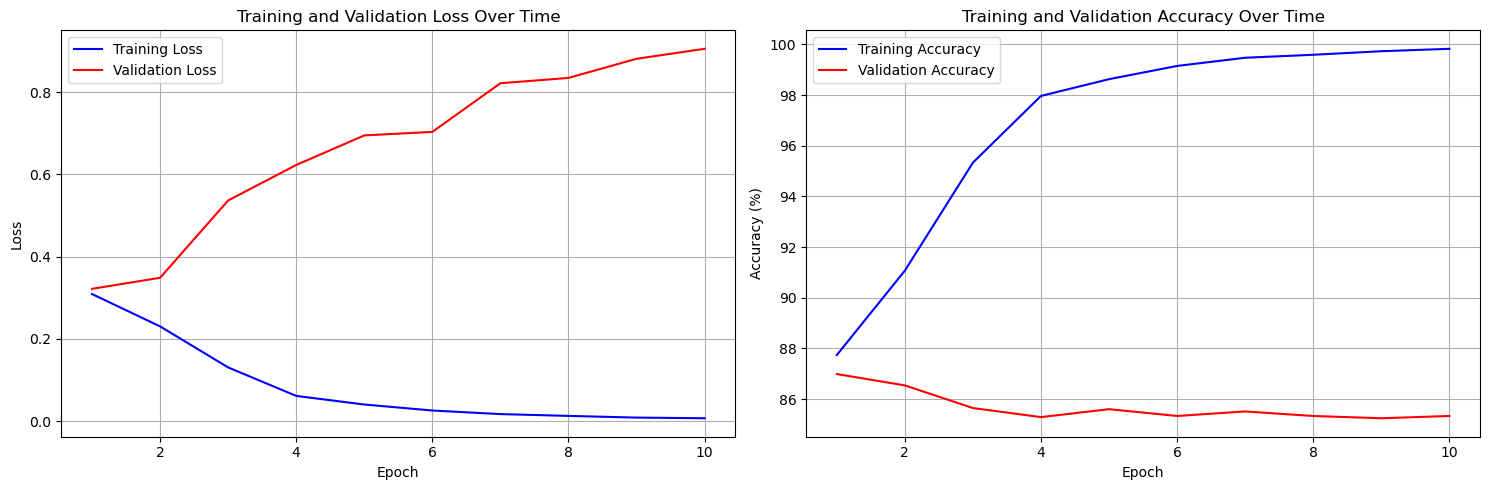


Final Results:
Best Validation Accuracy: 86.99%

Training History:
Epoch 1:
  Training   - Loss: 0.3090, Accuracy: 87.74%
  Validation - Loss: 0.3217, Accuracy: 86.99%
Epoch 2:
  Training   - Loss: 0.2304, Accuracy: 91.07%
  Validation - Loss: 0.3486, Accuracy: 86.54%
Epoch 3:
  Training   - Loss: 0.1306, Accuracy: 95.33%
  Validation - Loss: 0.5366, Accuracy: 85.65%
Epoch 4:
  Training   - Loss: 0.0613, Accuracy: 97.96%
  Validation - Loss: 0.6229, Accuracy: 85.29%
Epoch 5:
  Training   - Loss: 0.0404, Accuracy: 98.63%
  Validation - Loss: 0.6948, Accuracy: 85.61%
Epoch 6:
  Training   - Loss: 0.0258, Accuracy: 99.15%
  Validation - Loss: 0.7034, Accuracy: 85.34%
Epoch 7:
  Training   - Loss: 0.0171, Accuracy: 99.47%
  Validation - Loss: 0.8216, Accuracy: 85.52%
Epoch 8:
  Training   - Loss: 0.0127, Accuracy: 99.59%
  Validation - Loss: 0.8346, Accuracy: 85.34%
Epoch 9:
  Training   - Loss: 0.0086, Accuracy: 99.73%
  Validation - Loss: 0.8811, Accuracy: 85.25%
Epoch 10:
  Training   

In [73]:
# Plotting training and validation metrics
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("\nTraining History:")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    print(
        f"  Training   - Loss: {train_losses[epoch]:.4f}, Accuracy: {train_accs[epoch]:.2f}%")
    print(
        f"  Validation - Loss: {val_losses[epoch]:.4f}, Accuracy: {val_accs[epoch]:.2f}%")

In [75]:
# Load best model
model.load_state_dict(torch.load(
    
    # path/'models/best_multimodal_informative.pth'))
    path/'models/informative_Attention_graph_V2.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')







e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "












































































































































































































































































































































































































































































































































































Evaluating: 100%|██████████| 140/140 [07:27<00:00,  3.19s/it, acc=88.42%, loss=0.2889]


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.71      0.77       625
           1       0.89      0.95      0.92      1612

    accuracy                           0.88      2237
   macro avg       0.87      0.83      0.85      2237
weighted avg       0.88      0.88      0.88      2237



ValueError: too many values to unpack (expected 2)

Getting test set predictions...




e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "






















































































































































































































































































Getting predictions: 100%|██████████| 140/140 [08:03<00:00,  3.46s/it]


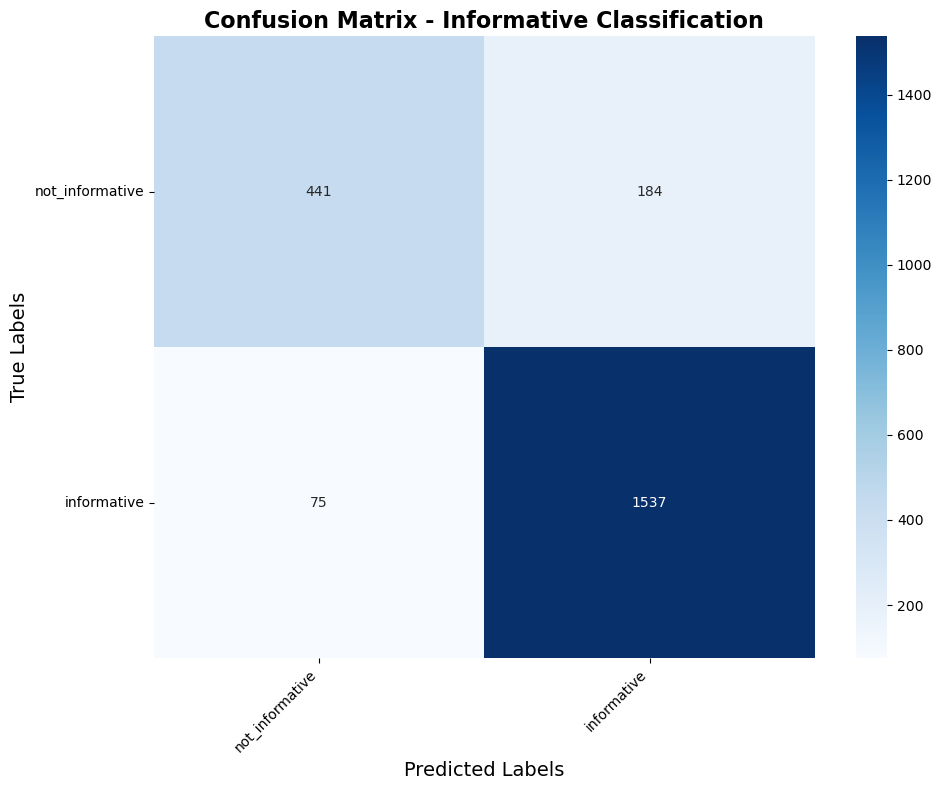

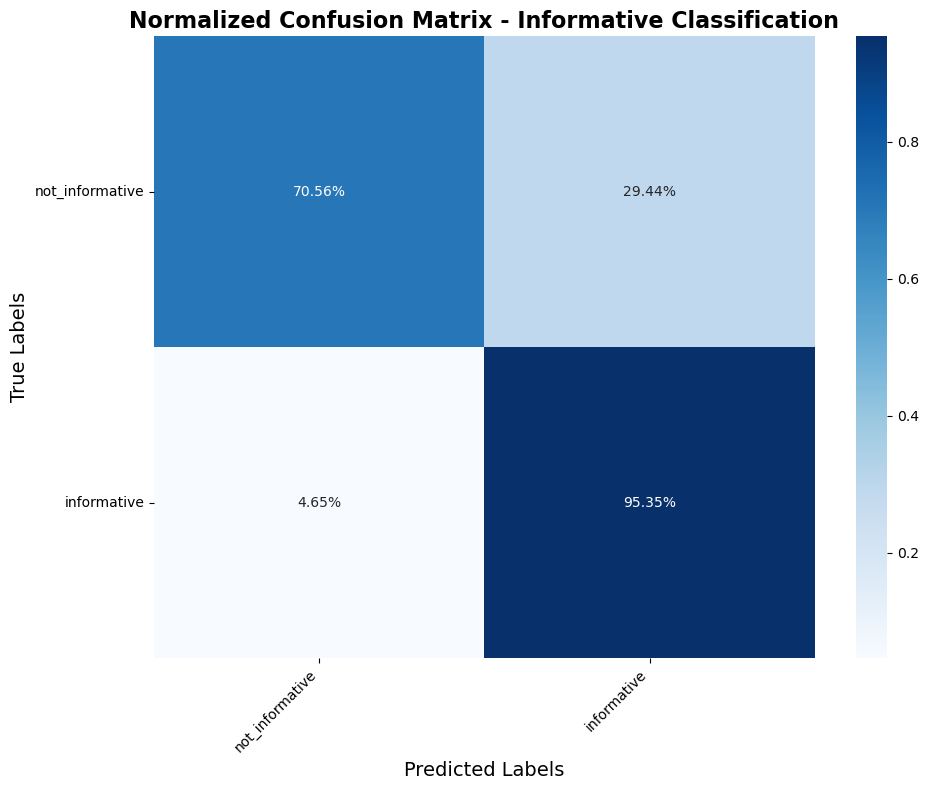


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     0.8547    0.7056    0.7730       625
    informative     0.8931    0.9535    0.9223      1612

       accuracy                         0.8842      2237
      macro avg     0.8739    0.8295    0.8476      2237
   weighted avg     0.8823    0.8842    0.8806      2237


PER-CLASS ACCURACY ANALYSIS
not_informative          : 0.7056 (441/625 samples)
informative              : 0.9535 (1537/1612 samples)


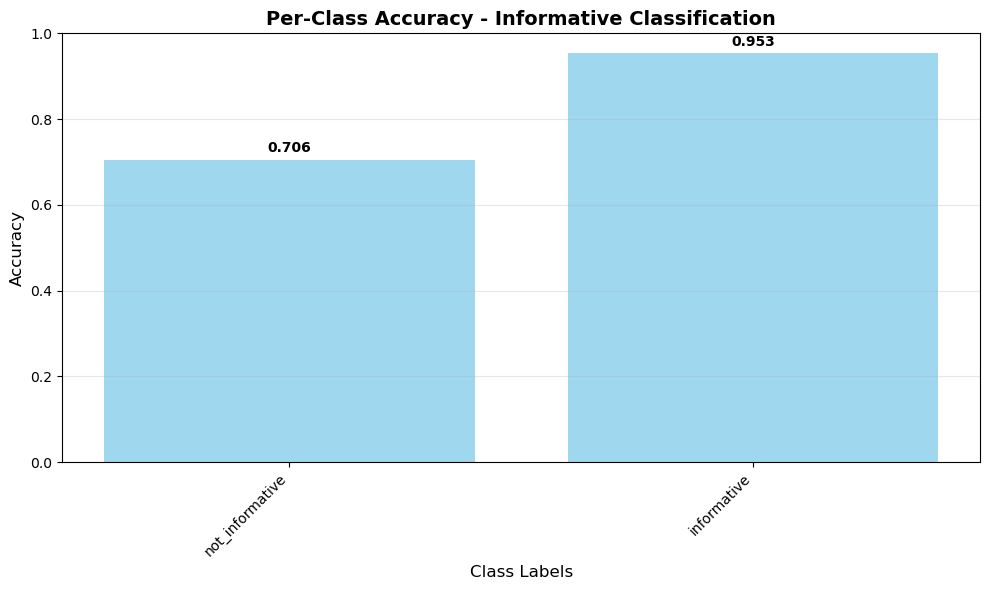


SUMMARY STATISTICS
Overall Test Accuracy: 0.8842
Best Performing Class: informative (0.9535)
Worst Performing Class: not_informative (0.7056)
Average Per-Class Accuracy: 0.8295
Standard Deviation: 0.1239

CLASS DISTRIBUTION IN TEST SET
not_informative          :  625 samples (27.9%)
informative              : 1612 samples (72.1%)

BINARY CLASSIFICATION METRICS
True Negatives:  441
False Positives: 184
False Negatives: 75
True Positives:  1537

Precision (Informative): 0.8931
Recall (Informative):    0.9535
Specificity:             0.7056
F1-Score:                0.9223


In [76]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")

: 

: 

: 





e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "



























































































































































































































































































1) Main Performance Table


,Accuracy,Precision_macro,Recall_macro,F1_macro
Full Model,0.8842,0.8739,0.8295,0.8476






e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "




























































































































































































































































































e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "



















































































































































































































2) Ablation Table


...


5) Efficiency Table


,Total_params,Trainable_params,Approx_model_size_MB,Latency_ms_per_sample,Throughput_samples_per_sec
0,136534850,136534850,520.8391,208.2561,4.8018








e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "










































































































































































































































































































































































































































e:\notebooks\MultimodalTweetsClassification\venv\lib\site-packages\PIL\Image.py:993: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "



































































6) Robustness Table


,Noise_std,Accuracy,F1_macro
0,0.00,0.8842,0.8476
1,0.01,0.8847,0.8483
2,0.03,0.8838,0.8471
3,0.05,0.8833,0.8466


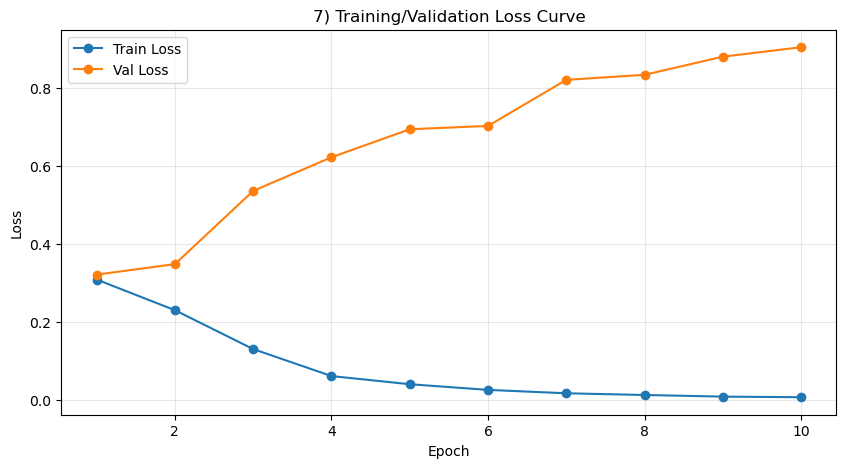

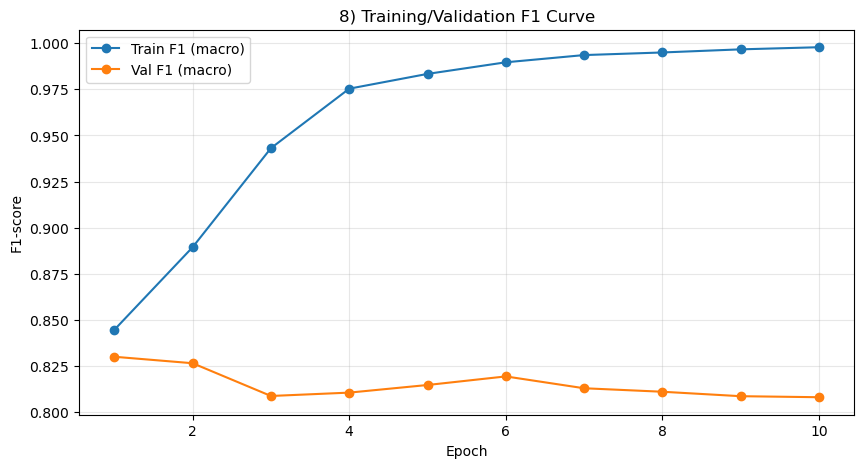

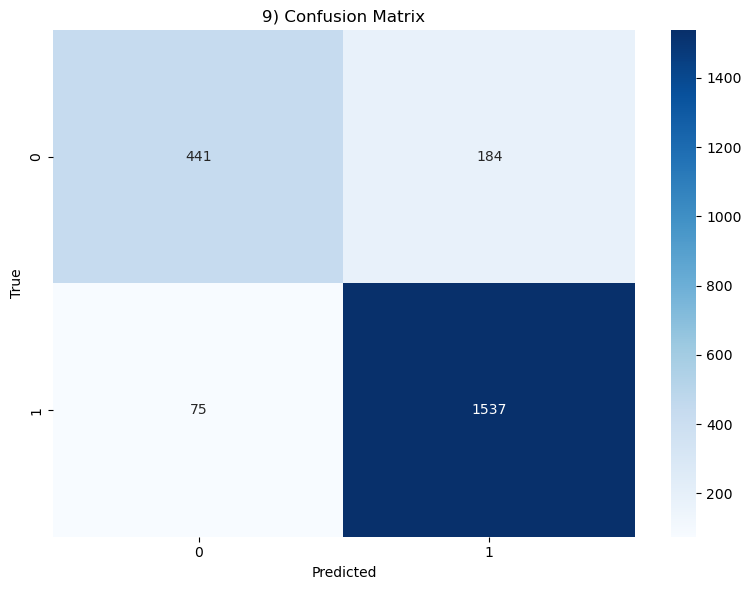

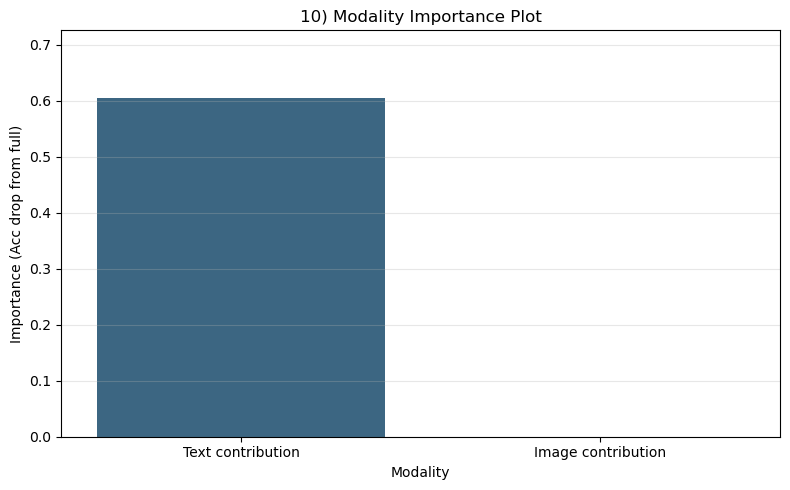

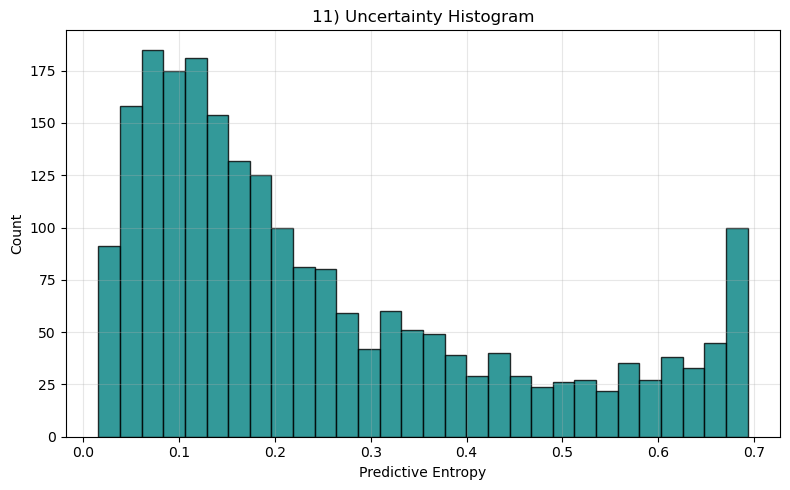

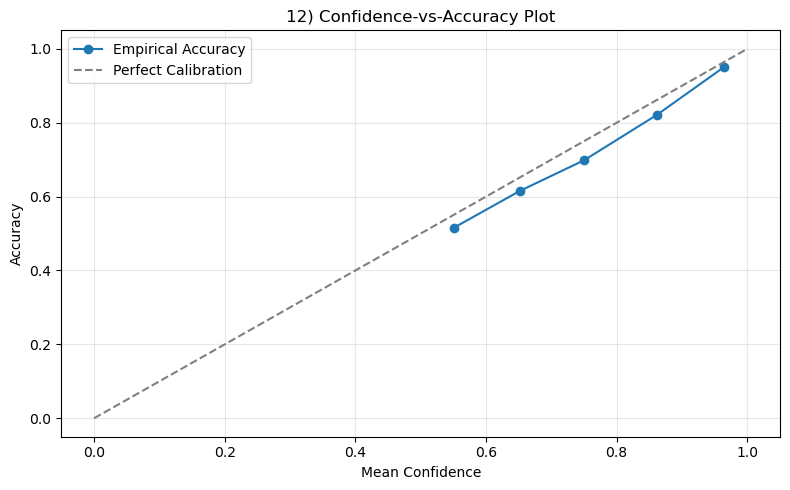

13) Attention Heatmap could not be generated: forward() got an unexpected keyword argument 'output_attentions'

Results section completed.


In [77]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score
    )


def _forward_with_mode(model, images, input_ids, attention_mask, mode='full'):
    if mode == 'text_only':
        images = torch.zeros_like(images)
    elif mode == 'image_only':
        input_ids = torch.zeros_like(input_ids)
        attention_mask = torch.zeros_like(attention_mask)
    return model(images, input_ids, attention_mask)


@torch.no_grad()
def collect_predictions(model, loader, device, mode='full', max_batches=None, image_noise_std=0.0):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for b_idx, batch in enumerate(tqdm(loader, desc=f'Collecting ({mode})', leave=False), 1):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        if image_noise_std > 0:
            noise = torch.randn_like(images) * image_noise_std
            images = torch.clamp(images + noise, -3.0, 3.0)

        outputs = _forward_with_mode(model, images, input_ids, attention_mask, mode=mode)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if max_batches is not None and b_idx >= max_batches:
            break

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_summary_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_macro': p,
        'Recall_macro': r,
        'F1_macro': f1
    }


def print_table(title, df):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")
    display(df)


# 1) Main performance table (Full model on test set)
y_true_full, y_pred_full, y_prob_full = collect_predictions(model, test_loader, device, mode='full')
main_metrics = compute_summary_metrics(y_true_full, y_pred_full)
main_perf_df = pd.DataFrame([main_metrics], index=['Full Model'])
print_table('1) Main Performance Table', main_perf_df.round(4))


# 2) Ablation table
ablation_rows = []
for mode_name, mode in [('Full', 'full'), ('Text only', 'text_only'), ('Image only', 'image_only')]:
    y_t, y_p, _ = collect_predictions(model, test_loader, device, mode=mode)
    m = compute_summary_metrics(y_t, y_p)
    m['Setting'] = mode_name
    ablation_rows.append(m)
ablation_df = pd.DataFrame(ablation_rows).set_index('Setting')
print_table('2) Ablation Table', ablation_df.round(4))


# 3) Per-class metrics table
per_class_report = classification_report(
    y_true_full, y_pred_full, output_dict=True, zero_division=0
    )
per_class_df = pd.DataFrame(per_class_report).T
per_class_df = per_class_df[~per_class_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
print_table('3) Per-Class Metrics Table', per_class_df.round(4))


# 4) Uncertainty-performance table
eps = 1e-12
uncertainty = -np.sum(y_prob_full * np.log(y_prob_full + eps), axis=1)
confidence = np.max(y_prob_full, axis=1)
correct = (y_true_full == y_pred_full).astype(int)
u_df = pd.DataFrame({'uncertainty': uncertainty, 'correct': correct})
u_df['bin'] = pd.qcut(u_df['uncertainty'], q=5, duplicates='drop')
uncert_perf_df = u_df.groupby('bin').agg(
    Samples=('correct', 'count'),
    Accuracy=('correct', 'mean'),
    Uncertainty_mean=('uncertainty', 'mean')
).reset_index()
print_table('4) Uncertainty-Performance Table', uncert_perf_df.round(4))


# 5) Efficiency table (approximate benchmark on subset)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = (n_params * 4) / (1024 ** 2)

bench_batches = 20
start = time.time()
_ = collect_predictions(model, test_loader, device, mode='full', max_batches=bench_batches)
elapsed = time.time() - start
samples_bench = min(len(test_dataset), bench_batches * test_loader.batch_size)
ms_per_sample = (elapsed * 1000.0) / max(samples_bench, 1)
throughput = samples_bench / max(elapsed, 1e-9)

efficiency_df = pd.DataFrame([{
    'Total_params': n_params,
    'Trainable_params': n_trainable,
    'Approx_model_size_MB': model_size_mb,
    'Latency_ms_per_sample': ms_per_sample,
    'Throughput_samples_per_sec': throughput
}])
print_table('5) Efficiency Table', efficiency_df.round(4))


# 6) Robustness table (image noise stress test)
robust_rows = []
for sigma in [0.00, 0.01, 0.03, 0.05]:
    y_t, y_p, _ = collect_predictions(
        model, test_loader, device, mode='full', image_noise_std=sigma
    )
    robust_rows.append({
        'Noise_std': sigma,
        'Accuracy': accuracy_score(y_t, y_p),
        'F1_macro': f1_score(y_t, y_p, average='macro')
    })
robustness_df = pd.DataFrame(robust_rows)
print_table('6) Robustness Table', robustness_df.round(4))


# 7) Training/validation loss curve
if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Val Loss')
    plt.title('7) Training/Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 8) Training/validation F1 curve
if 'train_f1s' in globals() and 'val_f1s' in globals() and len(train_f1s) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_f1s) + 1), train_f1s, marker='o', label='Train F1 (macro)')
    plt.plot(range(1, len(val_f1s) + 1), val_f1s, marker='o', label='Val F1 (macro)')
    plt.title('8) Training/Validation F1 Curve')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 9) Confusion matrix
cm = confusion_matrix(y_true_full, y_pred_full)
class_names = sorted(list(set(y_true_full.tolist())))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('9) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 10) Modality importance plots
full_acc = ablation_df.loc['Full', 'Accuracy']
text_only_acc = ablation_df.loc['Text only', 'Accuracy']
image_only_acc = ablation_df.loc['Image only', 'Accuracy']
importance_df = pd.DataFrame({
    'Modality': ['Text contribution', 'Image contribution'],
    'Importance (Acc drop from full)': [
        max(full_acc - image_only_acc, 0),
        max(full_acc - text_only_acc, 0)
    ]
})
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')
plt.title('10) Modality Importance Plot')
plt.ylim(0, max(importance_df['Importance (Acc drop from full)'].max() * 1.2, 0.05))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 11) Uncertainty histogram
plt.figure(figsize=(8, 5))
plt.hist(uncertainty, bins=30, color='teal', alpha=0.8, edgecolor='black')
plt.title('11) Uncertainty Histogram')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12) Confidence-vs-accuracy plot
c_df = pd.DataFrame({'confidence': confidence, 'correct': correct})
c_df['bin'] = pd.cut(c_df['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
conf_acc = c_df.groupby('bin').agg(
    Accuracy=('correct', 'mean'),
    MeanConfidence=('confidence', 'mean'),
    Samples=('correct', 'count')
).reset_index()
plt.figure(figsize=(8, 5))
plt.plot(conf_acc['MeanConfidence'], conf_acc['Accuracy'], marker='o', label='Empirical Accuracy')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
plt.title('12) Confidence-vs-Accuracy Plot')
plt.xlabel('Mean Confidence')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 13) Attention heatmap (BERT final layer CLS attention over tokens)
try:
    sample_text = str(test_df.iloc[0]['tweet_text'])
    enc = tokenizer.encode_plus(
        sample_text,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    in_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        attn_out = model.text_encoder(
            input_ids=in_ids, attention_mask=attn_mask, output_attentions=True
        )

    # transformers v2.x: attentions are usually last item in output tuple
    attentions = attn_out[-1] if isinstance(attn_out, (tuple, list)) else None
    if attentions is not None and len(attentions) > 0:
        last_layer = attentions[-1][0]  # [heads, seq, seq]
        cls_to_tokens = last_layer[:, 0, :].mean(dim=0).cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(in_ids[0].cpu().numpy())

        valid_len = int(attn_mask[0].sum().item())
        cls_to_tokens = cls_to_tokens[:valid_len]
        tokens = tokens[:valid_len]

        plt.figure(figsize=(min(18, 0.35 * len(tokens) + 4), 3.5))
        sns.heatmap(
            cls_to_tokens.reshape(1, -1),
            cmap='magma',
            cbar=True,
            xticklabels=tokens,
            yticklabels=['CLS attention']
        )
        plt.title('13) Attention Heatmap (BERT CLS -> Tokens)')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('13) Attention Heatmap: attentions are not available from this model output.')
except Exception as e:
    print(f'13) Attention Heatmap could not be generated: {e}')

print('\nResults section completed.')

## 6. Results Section

This section generates the requested result artifacts:
- Main performance table
- Ablation table
- Per-class metrics table
- Uncertainty-performance table
- Efficiency table
- Robustness table
- Training/validation loss curve
- Training/validation F1 curve
- Confusion matrix
- Modality importance plots
- Uncertainty histogram
- Confidence-vs-accuracy plot
- Attention heatmap